# Case study: can an Italian pension fund hedge its longevity risk with a European mortality index?

**Business question.** Longevity risk can be transferred with *index-based* instruments, such as q-forwards and survivor
swaps, whose payoff depends on the published mortality of a reference population. These instruments are cheaper and more
liquid than bespoke (indemnity) longevity swaps, but they leave **basis risk**: the hedger's own pensioners may not experience
the same improvements as the index. The risk committee of an Italian pension fund, or of the insurer that has taken over its
liabilities in a buy-in, asks:

1. How much of the decline in Italian mortality is common to Western Europe, and how much is specific to Italy?
2. Do *coherent* multi-population forecasts, which do not let countries drift apart indefinitely, forecast better than
   independent national models?
3. How much of the longevity risk of Italian male pensioners aged 65 can q-forwards on Italian, European or single-country
   indices remove? How much basis risk remains from the population, from the age profile and from the size of the fund?

**Data.** Eurostat deaths by single age (`demo_magec`) and population on 1 January (`demo_pjan`), men aged 50-89, Italy and
12 Western European countries, 1998-2024 (the longest window with complete single-age data for all of them). Discounting on
the ECB AAA curve of December 2024 extended with Smith-Wilson to a 3.3% ultimate forward rate.

**Model.** Li-Lee augmented common factor model (Li and Lee, 2005), fitted by Poisson maximum likelihood in two stages:
$\ln m_{x,t}^{G} = A_x + B_x K_t$ on the 13-country aggregate, then for each population $i$
$$\ln m_{x,t,i} = a_{x,i} + B_x K_t + b_{x,i}\, k_{t,i}, \qquad \textstyle\sum_x b_{x,i} = 1,\ \sum_t k_{t,i} = 0.$$
$K_t$ is a random walk with drift and each $k_{t,i}$ a zero-mean AR(1), so national deviations revert (coherence). The
innovations are jointly Gaussian. The pandemic years 2020-2022 get zero weight.

**Conventions.** Ages last birthday, calendar years, central exposures from the average of consecutive 1 January
populations, constant force of mortality within each year of age ($q = 1 - e^{-m}$). Valuation at 31 December 2024; a life
aged 65 at valuation experiences in year $2024 + h$ the rate of age $64 + h$.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "longevity_risk").is_dir())
try:
    import longevity_risk
except ImportError:  # not installed: use the source folder
    sys.path.insert(0, str(ROOT / "scripts" / "longevity_risk"))
    import longevity_risk
from longevity_risk import curves, data, lee_carter as lc, multipopulation as mp, synthetic

DATA_MODE = os.environ.get("LONGEVITY_RISK_DATA_MODE", "official")  # "official" (Eurostat + ECB) or "synthetic"
HOME = "IT"
PEERS = mp.PEERS                   # France, Germany, Spain, Netherlands, Belgium, Austria, Sweden, Denmark,
                                   # Portugal, Switzerland, Finland, Norway
COUNTRIES = (HOME,) + PEERS
SEX, AGES, FIRST_YEAR = "M", range(50, 90), 1998   # longest window with complete single-age data for all 13
PANDEMIC_YEARS = (2020, 2021, 2022)                  # zero weight in the fit, as in the Lee-Carter notebook
BACKTEST_FIT, BACKTEST_TEST = range(1998, 2013), range(2013, 2020)
PHI_MAX = 0.98
AGE0, HEDGE_HORIZON, OMEGA = 65, 10, 110
HEDGE_AGES = [70, 75, 80, 85]
INDICES = ["IT", "EU peers", "DE", "FR", "ES", "NL"]
UFR, LLP = 0.033, 20
N_SCENARIOS = 20_000
SEED_CAL, SEED_TEST = 20240101, 20240102   # calibration and evaluation scenarios are independent
OUTPUT_DIR = ROOT / "outputs" / "multipopulation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print(f"longevity_risk {longevity_risk.__version__} | data mode: {DATA_MODE}")

longevity_risk 0.1.0 | data mode: official


## 1. Data

The peer group is also aggregated into a single population, **"EU peers"**, which plays the role of a European mortality index.
Temporary life expectancy between 65 and 90, $e_{65:\overline{25}|}$, uses only the observed ages, so it can be compared with
the data directly.

Source: Eurostat demo_magec and demo_pjan, geo=IT, sex=M
13 countries, ages 50-89, years 1998-2024; deaths in the sample: 35,329,390


,exposure 2019 (million),e(65:25) 1998,e(65:25) 2024,gain (years)
CH,1.591,16.025,19.031,3.006
SE,1.862,15.832,18.906,3.074
IT,12.229,15.513,18.630,3.117
NO,0.929,15.278,18.620,3.343
ES,8.634,15.616,18.481,2.866
FR,11.902,15.785,18.438,2.653
PT,1.974,14.663,18.117,3.454
NL,3.331,14.707,17.996,3.288
EU peers,53.289,15.240,17.964,2.723
BE,2.087,14.827,17.960,3.133


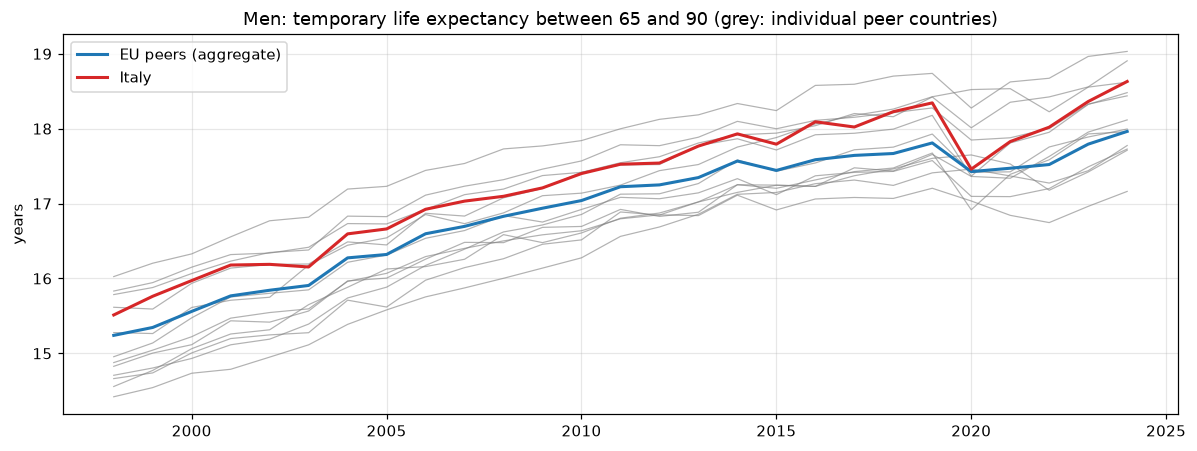

In [2]:
D, E = mp.load_panel(COUNTRIES, SEX, AGES, FIRST_YEAR, official=DATA_MODE == "official")
D["EU peers"], E["EU peers"] = mp.aggregate(D, E, PEERS)
years = D[HOME].columns.to_numpy()
fit_years = [y for y in years if y not in PANDEMIC_YEARS]
print("Source:", D[HOME].attrs.get("source", ""))
print(f"{len(COUNTRIES)} countries, ages {min(AGES)}-{max(AGES)}, years {years.min()}-{years.max()}; "
      f"deaths in the sample: {sum(D[c].to_numpy().sum() for c in COUNTRIES):,.0f}")

def e65_25(m):
    return mp.temporary_life_expectancy(np.asarray(m)[..., 15:40])   # ages 65-89

crude_e = pd.DataFrame({c: e65_25((D[c] / E[c]).to_numpy().T) for c in D}, index=years)
size = pd.Series({c: E[c].loc[:, 2019].sum() / 1e6 for c in D}, name="exposure 2019, million")
summary = pd.DataFrame({"exposure 2019 (million)": size, f"e(65:25) {years.min()}": crude_e.iloc[0],
                        f"e(65:25) {years.max()}": crude_e.iloc[-1],
                        "gain (years)": crude_e.iloc[-1] - crude_e.iloc[0]})
display(summary.sort_values(f"e(65:25) {years.max()}", ascending=False))

fig, ax = plt.subplots(figsize=(11, 4.2))
for c in PEERS:
    ax.plot(years, crude_e[c], color="grey", lw=0.8, alpha=0.6)
ax.plot(years, crude_e["EU peers"], color="C0", lw=2, label="EU peers (aggregate)")
ax.plot(years, crude_e[HOME], color="C3", lw=2, label="Italy")
ax.set(title="Men: temporary life expectancy between 65 and 90 (grey: individual peer countries)", ylabel="years")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "e65_25_by_country.png", dpi=150)

## 2. Li-Lee estimation

The deviance table compares, for each population, a static age-only model, the common factor alone ($a_{x,i} + B_x K_t$),
the Li-Lee model and an independent Lee-Carter fit. The explanation ratios are the Poisson-deviance analogue of Li and Lee's
$R$ ratios: the share of the static model's deviance removed by the common factor alone ($R_{\text{common}}$) and by the full
model ($R_{\text{Li-Lee}}$).

two-stage Poisson fit of 14 populations in 0.2 s


,IT,FR,DE,ES,NL,BE,AT,SE,DK,PT,CH,FI,NO,EU peers
R common,0.930,0.935,0.826,0.955,0.917,0.910,0.856,0.924,0.885,0.886,0.908,0.867,0.882,0.968
R Li-Lee,0.961,0.962,0.918,0.977,0.971,0.952,0.903,0.954,0.925,0.946,0.943,0.913,0.943,0.985


Italy: the common factor explains 93.0% of the deviance of the static model, the Li-Lee model 96.1%


Country-specific effect on e(65:25), years, over the fitted years:


,IT,FR,DE,ES,NL,BE,AT,SE,DK,PT,CH,FI,NO,EU peers
min,-0.090,-0.120,-0.490,-0.090,-0.450,-0.070,-0.260,-0.120,-0.220,-0.260,-0.180,-0.070,-0.390,-0.120
max,0.020,0.090,0.250,0.140,0.280,0.160,0.180,0.330,0.310,0.400,0.240,0.060,0.460,0.080


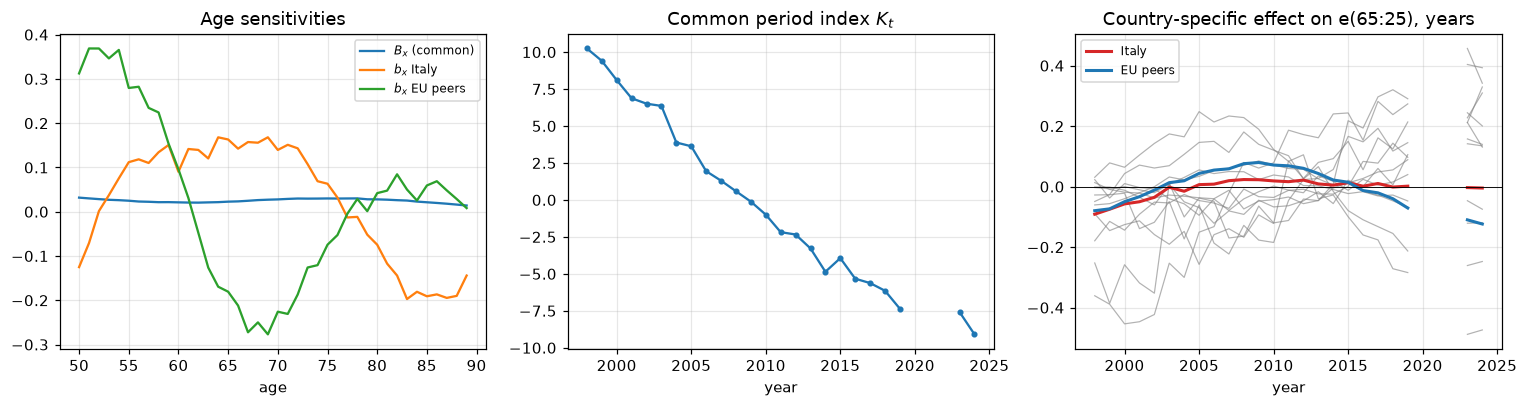

In [3]:
t0 = time.perf_counter()
fit = mp.fit_li_lee(D, E, COUNTRIES, fit_years)
print(f"two-stage Poisson fit of {len(D)} populations in {time.perf_counter() - t0:.1f} s")
display(fit.deviance[["R common", "R Li-Lee"]].T)
print(f"Italy: the common factor explains {100 * fit.deviance.loc[HOME, 'R common']:.1f}% of the deviance of the static model, "
      f"the Li-Lee model {100 * fit.deviance.loc[HOME, 'R Li-Lee']:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(fit.ages, fit.B, label="$B_x$ (common)")
axes[0].plot(fit.ages, fit.b[HOME], label="$b_{x}$ Italy")
axes[0].plot(fit.ages, fit.b["EU peers"], label="$b_{x}$ EU peers")
axes[0].set(title="Age sensitivities", xlabel="age")
axes[0].legend(fontsize=8)
axes[1].plot(years, fit.K, marker="o", ms=3)
axes[1].set(title="Common period index $K_t$", xlabel="year")
# The k_{t,i} are on different scales (the b_{x,i} have different age profiles): show their effect in years instead.
def country_effect(name):
    full = fit.log_rates(name).to_numpy()
    common = full - fit.b[name][:, None] * fit.k[name][None, :]
    return e65_25(np.exp(full).T) - e65_25(np.exp(common).T)

effects = pd.DataFrame({c: country_effect(c) for c in D}, index=years)
for c in PEERS:
    axes[2].plot(years, effects[c], color="grey", lw=0.8, alpha=0.6)
axes[2].plot(years, effects[HOME], color="C3", lw=2, label="Italy")
axes[2].plot(years, effects["EU peers"], color="C0", lw=2, label="EU peers")
axes[2].axhline(0, color="k", lw=0.6)
axes[2].set(title="Country-specific effect on e(65:25), years", xlabel="year")
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "li_lee_parameters.png", dpi=150)
print("Country-specific effect on e(65:25), years, over the fitted years:")
display(effects.loc[fit.mask].agg(["min", "max"]).round(2))

## 3. Dynamics

$K_t = K_{t-1} + d + \varepsilon_t$; $k_{t,i} = \phi_i k_{t-1,i} + \eta_{t,i}$. Innovations come from pairs of consecutive
fitted years (22 pairs: the pandemic gap is skipped). A least-squares $\hat\phi_i \ge 1$ means that the country kept
drifting away from the group in the sample. A coherent projection does not extrapolate such drift indefinitely, so
$\phi_i$ is capped at 0.98 (half-life of 34 years). The alternative with permanent deviations ($\phi_i = 1$) is kept as a
sensitivity.

In [4]:
dyn = mp.fit_dynamics(fit, phi_max=PHI_MAX)
dyn_rw = mp.fit_dynamics(fit, random_walk_deviations=True)
print(f"common drift d = {dyn.drift:.3f} per year (s.e. {dyn.drift_se:.3f}); innovation s.d. of K {np.sqrt(dyn.cov.loc['K', 'K']):.3f}")
ar = pd.DataFrame({"phi (least squares)": dyn.phi_unrestricted, "phi used": dyn.phi,
                   "innovation s.d.": pd.Series(np.sqrt(np.diag(dyn.cov)), index=dyn.cov.index).drop("K")})
ar["half-life (years)"] = np.log(0.5) / np.log(ar["phi used"])
display(ar.T)
keys = ["K", HOME, "EU peers", "DE", "FR", "ES", "NL"]
print("Correlation of innovations")
display(dyn.corr.loc[keys, keys].round(2))

common drift d = -0.744 per year (s.e. 0.149); innovation s.d. of K 0.715


,IT,FR,DE,ES,NL,BE,AT,SE,DK,PT,CH,FI,NO,EU peers
phi (least squares),0.781,0.984,1.013,0.765,0.935,0.918,1.007,1.138,0.943,0.928,0.819,1.017,0.849,1.003
phi used,0.781,0.980,0.980,0.765,0.935,0.918,0.980,0.980,0.943,0.928,0.819,0.980,0.849,0.980
innovation s.d.,0.097,0.069,0.280,0.437,0.497,0.490,0.053,0.698,0.799,0.152,0.463,0.490,0.930,0.036
half-life (years),2.801,34.310,34.310,2.584,10.233,8.141,34.310,34.310,11.883,9.265,3.475,34.310,4.225,34.310


Correlation of innovations


,K,IT,EU peers,DE,FR,ES,NL
K,1.000,-0.550,0.150,-0.060,0.270,0.330,-0.290
IT,-0.550,1.000,-0.390,0.360,-0.500,-0.450,0.730
EU peers,0.150,-0.390,1.000,-0.570,0.870,0.390,-0.140
DE,-0.060,0.360,-0.570,1.000,-0.600,-0.600,0.140
FR,0.270,-0.500,0.870,-0.600,1.000,0.360,-0.070
ES,0.330,-0.450,0.390,-0.600,0.360,1.000,-0.390
NL,-0.290,0.730,-0.140,0.140,-0.070,-0.390,1.000


## 4. Out-of-sample backtest: coherent versus independent forecasts

Both models are fitted on 1998-2012 only and forecast 2013-2019 (the last pre-pandemic year): the Li-Lee central projection
($K$ on its drift, $k_i$ decaying at $\phi_i$) against an independent Poisson Lee-Carter model with a random walk with drift for each
country. Accuracy is the root mean squared error of the log death rates over all ages and years, and the error in
$e_{65:\overline{25}|}$ in 2019.

In [5]:
fy, ty = list(BACKTEST_FIT), list(BACKTEST_TEST)
Dfit = {k: v.loc[:, fy] for k, v in D.items()}
Efit = {k: v.loc[:, fy] for k, v in E.items()}
bt_fit = mp.fit_li_lee(Dfit, Efit, COUNTRIES)
bt_dyn = mp.fit_dynamics(bt_fit, phi_max=PHI_MAX)
rows = {}
for name in D:
    Kc, kc = mp.central_states(bt_dyn, name, len(ty))
    ll = bt_fit.a[name][:, None] + bt_fit.B[:, None] * Kc[None, :] + bt_fit.b[name][:, None] * kc[None, :]
    own = lc.fit_poisson(Dfit[name], Efit[name])
    rw = lc.RandomWalkDrift.from_kt(own.years, own.kt)
    ind = own.ax[:, None] + own.bx[:, None] * rw.central_path(len(ty))[None, :]
    actual = np.log(D[name].loc[:, ty] / E[name].loc[:, ty]).to_numpy()
    e_act = crude_e.loc[ty[-1], name]
    rows[name] = {"RMSE Li-Lee": np.sqrt(np.mean((actual - ll) ** 2)), "RMSE independent": np.sqrt(np.mean((actual - ind) ** 2)),
                  "e(65:25) 2019 actual": e_act,
                  "error Li-Lee": e65_25(np.exp(ll[:, -1])) - e_act, "error independent": e65_25(np.exp(ind[:, -1])) - e_act}
backtest = pd.DataFrame(rows).T
backtest["Li-Lee better"] = backtest["RMSE Li-Lee"] < backtest["RMSE independent"]
display(backtest)
print(f"Li-Lee has the lower RMSE for {backtest['Li-Lee better'].sum()} of {len(backtest)} populations; "
      f"median RMSE ratio {np.median(backtest['RMSE Li-Lee'] / backtest['RMSE independent']):.2f}")

,RMSE Li-Lee,RMSE independent,e(65:25) 2019 actual,error Li-Lee,error independent,Li-Lee better
IT,0.047,0.068,18.344,0.081,0.075,True
FR,0.080,0.087,18.277,0.355,0.395,True
DE,0.085,0.096,17.205,0.593,0.557,True
ES,0.068,0.055,18.178,0.221,0.209,False
NL,0.051,0.060,17.928,0.070,0.263,True
BE,0.090,0.096,17.675,0.182,0.101,True
AT,0.100,0.105,17.574,0.429,0.509,True
SE,0.080,0.070,18.424,0.101,0.018,False
DK,0.100,0.121,17.410,0.055,0.329,True
PT,0.074,0.088,17.657,0.015,0.227,True


Li-Lee has the lower RMSE for 9 of 14 populations; median RMSE ratio 0.92


## 5. Coherent projections to 2050

Central period life expectancy at 65 (rates extended to age 110 with a Gompertz extrapolation of $a_{x,i}$, as in the
Lee-Carter notebook). Independent models let each country extrapolate its own recent trend; the Li-Lee model makes the
national deviations fade. The simulated gap between Italy and the European index in 2050 shows how much divergence each
dynamic allows.

,e65 2024 (model),e65 2050 Li-Lee,e65 2050 independent
FR,19.992,23.645,23.817
CH,20.571,23.611,24.409
SE,20.220,23.359,24.076
ES,19.987,23.208,23.899
IT,19.693,23.111,23.500
NO,19.904,22.825,23.970
EU peers,19.185,22.815,22.760
AT,18.803,22.490,22.381
BE,19.200,22.473,23.342
PT,19.381,22.375,23.920


range across the 13 countries in 2050 (years): {'e65 2050 Li-Lee': 1.63, 'e65 2050 independent': 3.33}


,mean,5%,95%
coherent (AR(1)),0.297,0.143,0.448
permanent deviations (random walk),0.368,-0.119,0.866


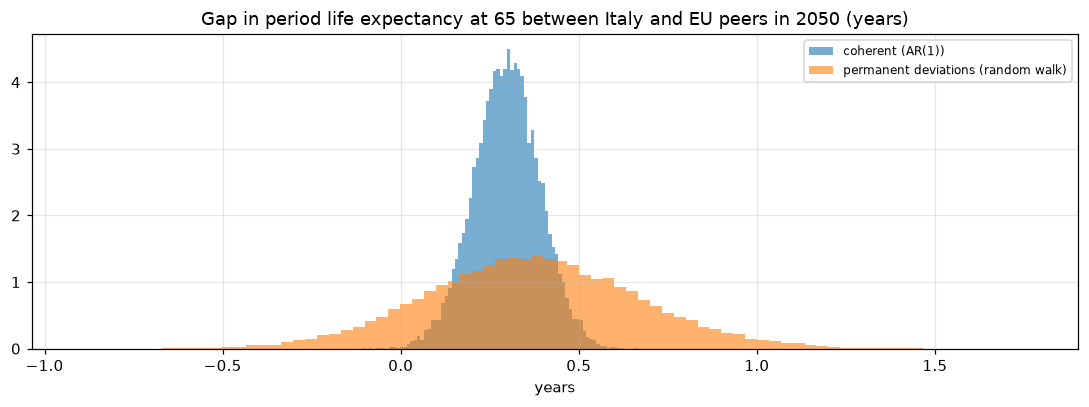

In [6]:
H50 = 2050 - dyn.last_year
proj = {}
for name in D:
    Kc, kc = mp.central_states(dyn, name, H50)
    proj[name] = {"e65 2024 (model)": float(mp.period_e(fit, name, dyn.K_last, dyn.k_last[name], omega=OMEGA)),
                  "e65 2050 Li-Lee": float(mp.period_e(fit, name, Kc[-1], kc[-1], omega=OMEGA)),
                  "e65 2050 independent": float(mp.independent_forecast_e(D[name], E[name], fit_years, H50, omega=OMEGA)[-1])}
proj = pd.DataFrame(proj).T
display(proj.sort_values("e65 2050 Li-Lee", ascending=False))
spread = proj[["e65 2050 Li-Lee", "e65 2050 independent"]].loc[list(COUNTRIES)].agg(lambda s: s.max() - s.min())
print("range across the 13 countries in 2050 (years):", spread.round(2).to_dict())

gaps = {}
for label, d_ in (("coherent (AR(1))", dyn), ("permanent deviations (random walk)", dyn_rw)):
    st = mp.simulate_states(d_, [HOME, "EU peers"], H50, N_SCENARIOS, seed=SEED_CAL)
    gaps[label] = (mp.period_e(fit, HOME, st["K"][:, -1], st[HOME][:, -1], omega=OMEGA)
                   - mp.period_e(fit, "EU peers", st["K"][:, -1], st["EU peers"][:, -1], omega=OMEGA))
display(pd.DataFrame({k: {"mean": v.mean(), "5%": np.quantile(v, 0.05), "95%": np.quantile(v, 0.95)} for k, v in gaps.items()}).T)
fig, ax = plt.subplots(figsize=(10, 3.8))
for label, v in gaps.items():
    ax.hist(v, bins=80, alpha=0.6, density=True, label=label)
ax.set(title="Gap in period life expectancy at 65 between Italy and EU peers in 2050 (years)", xlabel="years")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "e65_gap_2050.png", dpi=150)

## 6. Hedging an Italian pension liability with index q-forwards

**Liability.** An annuity-due of 1 a year to Italian men aged 65 at valuation. Its value is split at the hedge horizon of
10 years: payments in years 0-9 on the simulated survivors, plus the best-estimate annuity of the survivors at 75. That annuity
is re-projected from the simulated mortality state in 2034, which is how an insurer would revalue the liability at that date.
A finite fund has binomial deaths on top of the trend (sampling risk).

**Hedge.** q-forwards maturing in 2034 on the realised 2034 death probability of an index population at one age (75) or at
four ages (70, 75, 80, 85). The hedger receives fixed and pays realised mortality, so it gains when mortality falls.
Notionals are the least-squares hedge ratios estimated on 20,000 calibration scenarios; effectiveness is measured on
20,000 independent scenarios:
$\text{HE} = 1 - \operatorname{Var}(L - H)/\operatorname{Var}(L)$, together with the reduction of the 99.5% value at risk
(quantile minus mean). Parameter uncertainty in the common drift is included.

In [7]:
if DATA_MODE == "official":
    svensson = data.load_ecb_svensson_parameters("2024-12-01", "2024-12-31")
else:
    svensson = synthetic.svensson_parameters()
sw = curves.smith_wilson_from_svensson(curves.SvenssonCurve.from_series(svensson.iloc[-1]), UFR, LLP)
v = sw.discount(np.arange(0, OMEGA - AGE0 + 2.0))

def effectiveness(dynamics, horizon=HEDGE_HORIZON, sizes=(0, 10_000, 1_000)):
    cal = mp.simulate_states(dynamics, INDICES, OMEGA - AGE0 + 1, N_SCENARIOS, seed=SEED_CAL)
    test = mp.simulate_states(dynamics, INDICES, OMEGA - AGE0 + 1, N_SCENARIOS, seed=SEED_TEST)
    rows, liabilities = {}, {}
    for n_lives in sizes:
        Lc = mp.liability_values(fit, dynamics, HOME, cal, AGE0, horizon, v, n_lives, seed=1)
        Lt = mp.liability_values(fit, dynamics, HOME, test, AGE0, horizon, v, n_lives, seed=2)
        liabilities[n_lives] = Lt
        for index in INDICES:
            for ages in ([75], HEDGE_AGES):
                he = mp.hedge_effectiveness(Lc, mp.index_death_rates(fit, index, cal, ages, horizon), Lt,
                                            mp.index_death_rates(fit, index, test, ages, horizon))
                rows[("infinite" if n_lives == 0 else f"{n_lives:,} lives", index, "age 75" if len(ages) == 1 else "ages 70-85")] = he
    table = pd.DataFrame(rows).T
    table.index.names = ["fund size", "index", "q-forwards"]
    return table, liabilities

t0 = time.perf_counter()
he_coh, L_coh = effectiveness(dyn)
he_rw, L_rw = effectiveness(dyn_rw)
print(f"hedge simulations in {time.perf_counter() - t0:.1f} s")
L0 = L_coh[0]
print(f"liability per unit of annual pension: mean {L0.mean():.3f}, s.d. {L0.std():.3f} ({100 * L0.std() / L0.mean():.2f}%), "
      f"99.5% VaR {np.quantile(L0, 0.995) - L0.mean():.3f}")
def pivot(measure):
    both = pd.concat({"coherent": he_coh[measure], "permanent deviations": he_rw[measure]}, axis=1).astype(float)
    out = (100 * both).unstack("q-forwards")
    order = list(dict.fromkeys(he_coh.index.droplevel("q-forwards")))
    return out.reindex(order).round(1)

print("Variance reduction (%), test scenarios")
display(pivot("variance reduction"))
print("Reduction of the 99.5% value at risk (%), test scenarios")
display(pivot("VaR reduction"))

hedge simulations in 3.4 s
liability per unit of annual pension: mean 16.588, s.d. 0.246 (1.49%), 99.5% VaR 0.629
Variance reduction (%), test scenarios


coherent            permanent deviations           
q-forwards              age 75 ages 70-85               age 75 ages 70-85
fund size    index                                                       
infinite     IT         98.600     99.000               76.000     99.000
             EU peers   98.000     98.700               89.800     95.300
             DE         91.900     98.700               77.100     95.500
             FR         98.100     98.800               89.400     95.900
             ES         98.500     98.800               93.200     94.400
             NL         82.700     98.900               51.300     95.700
10,000 lives IT         95.500     95.900               74.300     96.900
             EU peers   94.900     95.600               87.800     93.300
             DE         89.000     95.600               75.400     93.500
             FR         95.000     95.700               87.400     93.800
             ES         95.300     95.700               91.100     92.400
             NL         80.300     95.800               50.100     93.600
1,000 lives  IT         74.700     75.000               62.100     80.800
             EU peers   74.200     74.800               73.400     77.800
             DE         69.600     74.800               63.000     78.000
             FR         74.400     74.800               73.000     78.300
             ES         74.600     74.900               76.100     77.000
             NL         62.900     75.000               42.100     78.100

Reduction of the 99.5% value at risk (%), test scenarios


coherent            permanent deviations           
q-forwards              age 75 ages 70-85               age 75 ages 70-85
fund size    index                                                       
infinite     IT         86.700     90.100               51.300     89.500
             EU peers   85.100     89.000               68.300     78.900
             DE         71.000     89.000               52.000     79.500
             FR         85.500     89.000               67.500     80.200
             ES         86.800     89.100               74.000     76.800
             NL         57.500     89.500               30.300     79.800
10,000 lives IT         78.400     80.100               49.400     82.900
             EU peers   77.000     79.300               65.100     74.700
             DE         66.300     79.400               49.700     74.800
             FR         77.200     79.300               64.100     75.600
             ES         78.100     79.200               70.200     72.700
             NL         54.200     79.700               29.100     74.900
1,000 lives  IT         51.600     51.900               37.700     57.700
             EU peers   51.000     51.600               48.000     53.500
             DE         45.800     51.500               39.200     53.200
             FR         51.300     51.700               47.800     53.900
             ES         51.000     51.300               51.200     52.100
             NL         39.300     51.100               24.000     54.100

### Longer horizon and what the hedge looks like in money

A 20-year hedge covers more of the liability's trend risk, but more of it is also exposed to basis risk. The notionals are
shown for a fund paying **EUR 100 million a year** to 65-year-old men (about 5,000 pensioners with EUR 20,000 each): the
change in the fund's liability for a one-point change in each index death probability (in percentage points).

In [8]:
long_coh, _ = effectiveness(dyn, horizon=20, sizes=(0,))
long_rw, _ = effectiveness(dyn_rw, horizon=20, sizes=(0,))
horizon_table = pd.DataFrame({
    ("10 years", "coherent"): he_coh.xs("infinite")["variance reduction"],
    ("10 years", "permanent deviations"): he_rw.xs("infinite")["variance reduction"],
    ("20 years", "coherent"): long_coh.xs("infinite")["variance reduction"],
    ("20 years", "permanent deviations"): long_rw.xs("infinite")["variance reduction"]})
display((100 * horizon_table.astype(float)).round(1))

ANNUAL_PENSIONS = 100e6
single = pd.Series({index: ANNUAL_PENSIONS * float(np.ravel(he_coh.loc[("infinite", index, "age 75"), "notionals"])[0]) / 100 / 1e6
                    for index in INDICES}, name="EUR million per percentage point of q75 in 2034")
print("Single-age hedge: change in the liability for a one-point rise in the index death probability at 75 in 2034")
display(single.to_frame().T.round(1))
multi = pd.DataFrame({index: ANNUAL_PENSIONS * np.asarray(he_coh.loc[("infinite", index, "ages 70-85"), "notionals"]) / 100 / 1e6
                      for index in ["IT", "EU peers", "DE"]}, index=[f"q{a}" for a in HEDGE_AGES]).T
print("Four-age hedge, same units: large offsetting positions")
display(multi.round(1))

10 years                      20 years  \
                    coherent permanent deviations coherent   
index    q-forwards                                          
IT       age 75       98.600               76.000   94.400   
         ages 70-85   99.000               99.000   95.400   
EU peers age 75       98.000               89.800   93.900   
         ages 70-85   98.700               95.300   95.400   
DE       age 75       91.900               77.100   89.500   
         ages 70-85   98.700               95.500   95.400   
FR       age 75       98.100               89.400   93.900   
         ages 70-85   98.800               95.900   95.400   
ES       age 75       98.500               93.200   94.500   
         ages 70-85   98.800               94.400   95.400   
NL       age 75       82.700               51.300   84.600   
         ages 70-85   98.900               95.700   95.400   

                                          
                    permanent deviations  
index    q-forwards                       
IT       age 75                   68.300  
         ages 70-85               95.600  
EU peers age 75                   81.600  
         ages 70-85               89.200  
DE       age 75                   70.500  
         ages 70-85               89.400  
FR       age 75                   81.200  
         ages 70-85               90.200  
ES       age 75                   85.000  
         ages 70-85               87.700  
NL       age 75                   48.400  
         ages 70-85               90.100

Single-age hedge: change in the liability for a one-point rise in the index death probability at 75 in 2034


,IT,EU peers,DE,FR,ES,NL
EUR million per percentage point of q75 in 2034,-148.500,-132.300,-109.900,-149.700,-141.200,-118.100


Four-age hedge, same units: large offsetting positions


,q70,q75,q80,q85
IT,-953.500,526.300,28.800,-71.500
EU peers,-240.800,171.700,137.700,-163.000
DE,22.000,165.100,-0.400,-132.900


## 7. Conclusions for the risk committee

Results on official Eurostat data for men, ages 50-89, 1998-2024 (in synthetic mode the numbers differ).

**Common and national mortality.**

- Italian men gained 3.1 years of temporary life expectancy between 65 and 90 from 1998 to 2024 (15.5 to 18.6), the third
  highest level among the 13 countries after Switzerland and Sweden. The European common factor explains 93.0% of the
  deviance of a static model for Italy (96.1% with the Italian factor). The Italy-specific component never moved $e_{65:\overline{25}|}$
  by more than 0.1 years: Italy tracks the European trend closely. Germany is the least aligned country (82.6%).
- Italy's deviation from the common trend is strongly mean-reverting ($\phi = 0.78$, half-life under 3 years). Germany,
  Austria, Sweden, Finland and the peer aggregate show $\hat\phi \ge 1$ (persistent divergence in the sample) and are capped
  at 0.98.
- **Out of sample** (fitted on 1998-2012, tested on 2013-2019) the coherent model has a lower RMSE of log death rates for
  Italy (0.047 against 0.068) and for 9 of the 14 populations (median ratio 0.92). Both models overestimated the 2019
  life expectancy of most countries, because improvements slowed in the 2010s.
- To 2050 the Li-Lee model keeps the 13 countries within 1.6 years of period life expectancy at 65, against 3.3 years for
  independent models. The 90% interval of the Italy - EU gap is 0.1 to 0.4 years with coherent dynamics and -0.1 to 0.9 years
  if national deviations are permanent.

**Hedging.**

- The value of an annuity of 1 a year to Italian men aged 65 is 16.59 with a standard deviation of 0.25 (1.5%) and a 99.5%
  value at risk of 0.63 (3.8%), measured on the 10-year value split.
- For a large fund, a single q-forward at age 75 on the **European peer index** removes 98.0% of the variance (85% of the
  99.5% VaR), against 98.6% (87%) for an Italian index. With coherent dynamics, population basis risk is small. Single
  countries are worse at one age (Germany 91.9%, the Netherlands 82.7%) because their own specific factor adds noise.
- **The answer depends on coherence.** If national deviations are permanent, the European index at age 75 removes 89.8%
  of the variance over 10 years and 81.6% over 20 years. Surprisingly, a single-age Italian index is worse (76.0%): a hedge
  must match the liability's age profile as well as its population.
- Over 10 years, four-age hedges recover most of the gap in the model (95-99%), but they need large offsetting positions (for the Italian
  index about EUR -950 million at age 70 and +530 million at 75 per percentage point for a fund paying EUR 100 million a
  year). That gain comes from the model's age structure and would be fragile in practice. The single-age sensitivity is a
  more robust sizing guide: about EUR 130-150 million per percentage point of the index $q_{75}$ in 2034.
- **Sampling risk dominates small funds.** With 10,000 pensioners the best hedges remove about 96% of the variance; with
  1,000 only 75% (50% of the standard deviation), whatever the index, because random deaths in the fund cannot be hedged
  with an index.

**For the committee:** a large Italian fund, or an insurer with a large Italian annuity book, can hedge most of its
longevity *trend* risk with European index instruments. The evidence (fast mean reversion of Italy's deviation, the backtest,
Italy's small specific component) supports the coherent model, under which the basis risk is small. The residual risk is
model risk on coherence (up to 12 points less effectiveness over 20 years), sampling risk for funds below about 10,000
lives, and the socio-economic basis between pensioners and the national population, which is not modelled here. Small
funds are better served by an indemnity solution (buy-in or bespoke longevity swap).

**Limitations.** Men only; ages 50-89, extended to 110 with a Gompertz extrapolation; 22 annual innovations to estimate a
15-dimensional covariance matrix; pandemic years excluded; population (not pensioner) mortality; no risk premium in the
q-forward rates, no counterparty or collateral effects; hedge ratios computed within the model.